In [1]:
from google.colab import files
upload = files.upload()

Saving e_data.csv to e_data.csv


In [2]:
import pandas as pd
df = pd.read_csv("e_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     10000 non-null  object
 1   first_name      10000 non-null  object
 2   last_name       10000 non-null  object
 3   gender          10000 non-null  object
 4   age_group       10000 non-null  object
 5   signup_date     10000 non-null  object
 6   country         10000 non-null  object
 7   product_id      10000 non-null  object
 8   product_name    10000 non-null  object
 9   category        10000 non-null  object
 10  quantity        10000 non-null  int64 
 11  unit_price      10000 non-null  int64 
 12  order_id        10000 non-null  object
 13  order_date      10000 non-null  object
 14  order_status    10000 non-null  object
 15  payment_method  10000 non-null  object
 16  rating          10000 non-null  int64 
 17  review_text     10000 non-null  object
 18  review_

In [4]:
# checking the structure of the data
df.shape

(10000, 20)

In [5]:
df.size

200000

In [6]:
# checking missing values
df.isnull().sum()

,0
customer_id,0
first_name,0
last_name,0
gender,0
age_group,0
signup_date,0
country,0
product_id,0
product_name,0
category,0


In [7]:
''' NO MISSING VALUE '''


' NO MISSING VALUE '

In [8]:
# check for duplicate value
df.duplicated().sum()

''' NO DUPLICATE VALUES '''

' NO DUPLICATE VALUES '

In [9]:
# currently all date columns are stored as text
# converting them into datetime type
df["signup_date"] = pd.to_datetime(df["signup_date"], dayfirst = True)
df["order_date"] = pd.to_datetime(df["order_date"], dayfirst = True)
df["review_date"] = pd.to_datetime(df["review_date"], dayfirst = True)

In [10]:
# now once again check the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     10000 non-null  object        
 1   first_name      10000 non-null  object        
 2   last_name       10000 non-null  object        
 3   gender          10000 non-null  object        
 4   age_group       10000 non-null  object        
 5   signup_date     10000 non-null  datetime64[ns]
 6   country         10000 non-null  object        
 7   product_id      10000 non-null  object        
 8   product_name    10000 non-null  object        
 9   category        10000 non-null  object        
 10  quantity        10000 non-null  int64         
 11  unit_price      10000 non-null  int64         
 12  order_id        10000 non-null  object        
 13  order_date      10000 non-null  datetime64[ns]
 14  order_status    10000 non-null  object        
 15  pay

In [11]:
# checking for invalid dates

df[df["review_date"] < df["order_date"]]

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,quantity,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,4,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,2,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,4,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14
5,CUST2790,Shelby,Sutton,Other,Adults,2025-07-18,Canada,PROD108,Fitbit Versa 3,Electronics,5,229,ORD10005,2023-04-13,Returned,PayPal,3,very good,REV20005,2023-02-14
6,CUST2442,Jennifer,Baxter,Female,Senior,2023-11-30,France,PROD106,Instant Pot,Home & Kitchen,1,99,ORD10006,2023-12-31,Returned,Credit Card,4,very good,REV20006,2023-12-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9993,CUST5900,Jeffery,Joseph,Male,Teenagers,2021-07-26,USA,PROD111,Lego Star Wars Set,Toys,1,59,ORD19993,2025-05-21,Delivered,Cash on Delivery,5,good,REV29993,2023-10-06
9994,CUST5192,David,Sanchez,Other,Adults,2022-12-15,China,PROD112,Barbie Dreamhouse,Toys,1,199,ORD19994,2025-02-24,Returned,Credit Card,2,very good,REV29994,2023-09-05
9996,CUST4602,Stacy,Brown,Other,Teenagers,2023-08-30,Canada,PROD109,Kindle Paperwhite,Books,5,129,ORD19996,2025-08-05,Returned,PayPal,1,bad,REV29996,2024-09-13
9997,CUST1448,Sheila,Roberts,Other,Adults,2024-05-18,USA,PROD107,Dyson Vacuum,Home & Kitchen,5,399,ORD19997,2023-12-23,Returned,Cash on Delivery,3,average,REV29997,2023-09-13


In [12]:
df["order_date"].dtypes

dtype('<M8[ns]')

In [13]:
invalid_dates = df[df["review_date"] < df["order_date"]]
invalid_dates[["order_date","review_date"]].head(10)

,order_date,review_date
1,2024-08-12,2023-08-05
2,2024-08-04,2023-01-03
3,2025-05-23,2023-03-14
5,2023-04-13,2023-02-14
6,2023-12-31,2023-12-29
9,2025-05-16,2024-12-03
16,2025-05-22,2024-11-20
19,2024-10-21,2024-10-05
21,2025-07-20,2023-04-22
25,2024-05-21,2023-06-05


In [14]:
# Create Revenue Column
df["Revenue"] = df["quantity"] * df["unit_price"]

In [15]:
df

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,...,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_id,review_date,Revenue
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,...,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,REV20000,2025-06-06,687
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,...,59,ORD10001,2024-08-12,Pending,PayPal,2,average,REV20001,2023-08-05,236
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,...,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,REV20002,2023-01-03,118
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,REV20003,2023-03-14,1596
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,...,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,REV20004,2023-10-18,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST2529,Lisa,Coleman,Male,Senior,2023-01-06,UK,PROD109,Kindle Paperwhite,Books,...,129,ORD19995,2023-06-07,Delivered,PayPal,4,very good,REV29995,2024-07-30,645
9996,CUST4602,Stacy,Brown,Other,Teenagers,2023-08-30,Canada,PROD109,Kindle Paperwhite,Books,...,129,ORD19996,2025-08-05,Returned,PayPal,1,bad,REV29996,2024-09-13,645
9997,CUST1448,Sheila,Roberts,Other,Adults,2024-05-18,USA,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD19997,2023-12-23,Returned,Cash on Delivery,3,average,REV29997,2023-09-13,1995
9998,CUST1343,Paul,Lam,Male,Teenagers,2024-07-14,Canada,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD19998,2022-08-30,Cancelled,Credit Card,2,very good,REV29998,2025-07-07,1197


In [16]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_id', 'review_date',
       'Revenue'],
      dtype='object')

In [17]:
df["age_group"].value_counts()

,count
age_group,
Teenagers,3359
Senior,3342
Adults,3299


In [18]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_id', 'review_date',
       'Revenue'],
      dtype='object')

In [19]:
# removing unwanted spaces in the column_name if present
df.columns.str.strip()

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_id', 'review_date',
       'Revenue'],
      dtype='object')

In [20]:
# Validating ratings
df["rating"].value_counts()

,count
rating,
3,2025
2,2005
1,2002
4,1996
5,1972


In [21]:
df["quantity"].describe()

,quantity
count,10000.000000
mean,3.000800
std,1.416474
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [22]:
df[df["quantity"] <=0]

''' VALIDATE PRICES '''

' VALIDATE PRICES '

In [23]:
df[df["unit_price"] <=0]

''' VALIDATE PRICES '''

' VALIDATE PRICES '

In [24]:
# finding customer tenure

df["customer_tenure_days"] = (df["order_date"] - df["signup_date"]).dt.days

In [25]:
df["customer_tenure_days"]

,customer_tenure_days
0,379
1,354
2,383
3,-91
4,831
...,...
9995,152
9996,706
9997,-147
9998,-684


In [26]:
(df["customer_tenure_days"] < 0).sum()

np.int64(3103)

In [27]:
# dropping review_id
df.drop("review_id", axis = 1, inplace = True)

In [28]:
df["customer_id"].str.startswith("CUST").all()
# checking the correct customer_id format

np.True_

In [29]:
df

,customer_id,first_name,last_name,gender,age_group,signup_date,country,product_id,product_name,category,...,unit_price,order_id,order_date,order_status,payment_method,rating,review_text,review_date,Revenue,customer_tenure_days
0,CUST2353,Erica,Oliver,Female,Teenagers,2022-06-29,Canada,PROD108,Fitbit Versa 3,Electronics,...,229,ORD10000,2023-07-13,Pending,Credit Card,2,good,2025-06-06,687,379
1,CUST4463,Christopher,White,Male,Adults,2023-08-24,China,PROD103,Levi's Jeans,Apparel,...,59,ORD10001,2024-08-12,Pending,PayPal,2,average,2023-08-05,236,354
2,CUST4512,Spencer,Foster,Male,Senior,2023-07-18,Germany,PROD111,Lego Star Wars Set,Toys,...,59,ORD10002,2024-08-04,Delivered,Cash on Delivery,5,good,2023-01-03,118,383
3,CUST5711,Jessica,Harris,Male,Teenagers,2025-08-22,France,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD10003,2025-05-23,Delivered,Cash on Delivery,2,very good,2023-03-14,1596,-91
4,CUST1296,Amy,Johnson,Female,Teenagers,2021-03-23,Brazil,PROD105,Adidas Running Shoes,Apparel,...,110,ORD10004,2023-07-02,Returned,Cash on Delivery,1,very good,2023-10-18,110,831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST2529,Lisa,Coleman,Male,Senior,2023-01-06,UK,PROD109,Kindle Paperwhite,Books,...,129,ORD19995,2023-06-07,Delivered,PayPal,4,very good,2024-07-30,645,152
9996,CUST4602,Stacy,Brown,Other,Teenagers,2023-08-30,Canada,PROD109,Kindle Paperwhite,Books,...,129,ORD19996,2025-08-05,Returned,PayPal,1,bad,2024-09-13,645,706
9997,CUST1448,Sheila,Roberts,Other,Adults,2024-05-18,USA,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD19997,2023-12-23,Returned,Cash on Delivery,3,average,2023-09-13,1995,-147
9998,CUST1343,Paul,Lam,Male,Teenagers,2024-07-14,Canada,PROD107,Dyson Vacuum,Home & Kitchen,...,399,ORD19998,2022-08-30,Cancelled,Credit Card,2,very good,2025-07-07,1197,-684


In [30]:
df["category"]

,category
0,Electronics
1,Apparel
2,Toys
3,Home & Kitchen
4,Apparel
...,...
9995,Books
9996,Books
9997,Home & Kitchen
9998,Home & Kitchen


In [31]:
# validating country name
df["country"].value_counts()

,count
country,
France,1060
China,1054
Australia,1043
India,1036
Brazil,1019
Canada,997
USA,987
Japan,976
UK,943


In [32]:
# Python Eda

# revenue by category


import pandas as pd
import matplotlib.pyplot as plt

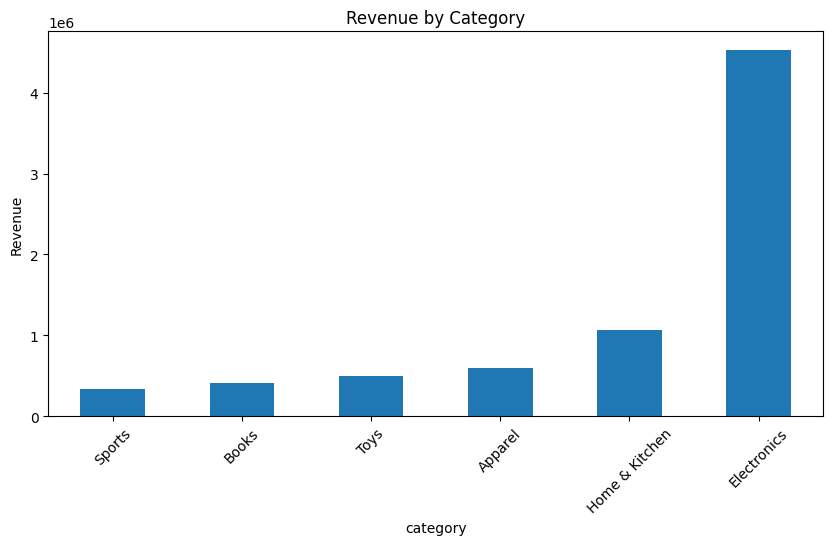

In [33]:
''' REVENUE BY CATEGORY '''
category_revenue = df.groupby("category")["Revenue"].sum().sort_values(ascending = True)
category_revenue

plt.figure(figsize = (10,5))
category_revenue.plot(kind = "bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

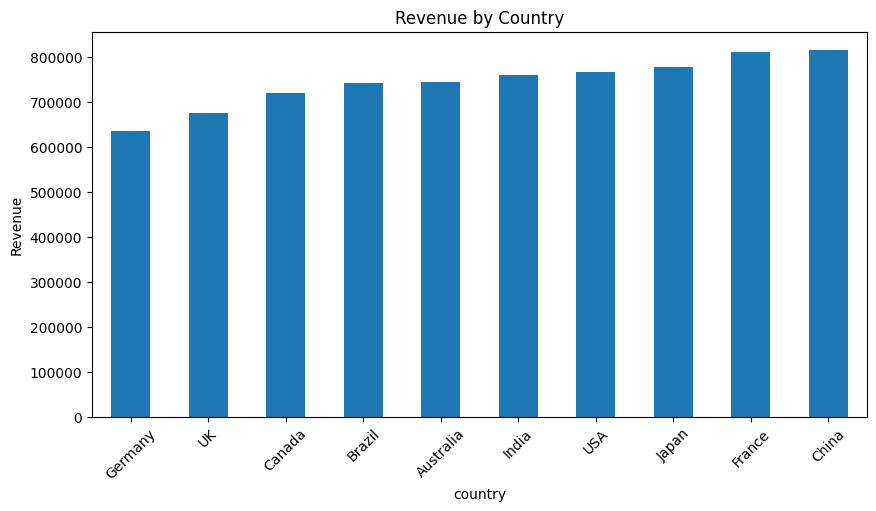

In [34]:
''' COUNTRY BY REVENUE'''
country_revenue = df.groupby("country")["Revenue"].sum().sort_values(ascending = True)
country_revenue

plt.figure(figsize = (10,5))
country_revenue.plot(kind = "bar")
plt.title("Revenue by Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

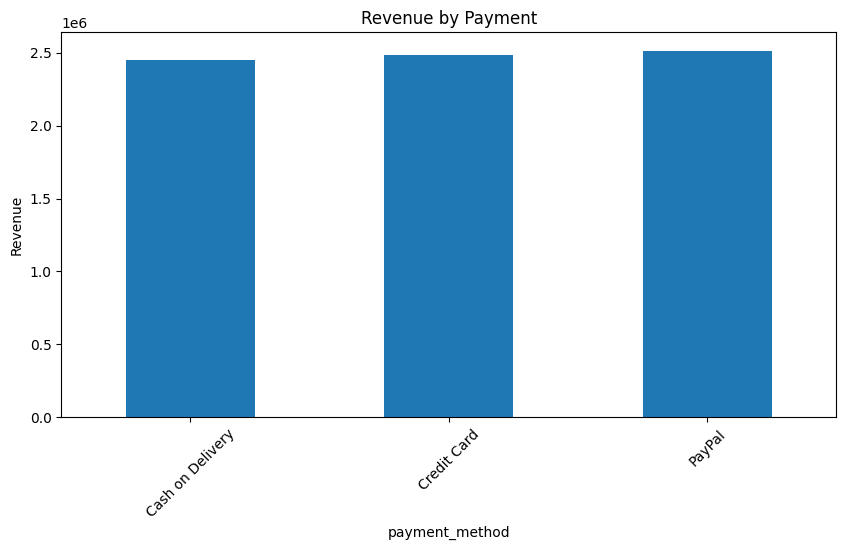

In [35]:
''' REVENUE BY PAYMENT METHOD '''
payment_revenue = df.groupby("payment_method")["Revenue"].sum().sort_values(ascending = True)
payment_revenue

plt.figure(figsize = (10,5))
payment_revenue.plot(kind = "bar")
plt.title("Revenue by Payment")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

In [36]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_date', 'Revenue',
       'customer_tenure_days'],
      dtype='object')

In [37]:
df["order_month"] = df["order_date"].dt.strftime("%Y-%m")
df["order_month"]

,order_month
0,2023-07
1,2024-08
2,2024-08
3,2025-05
4,2023-07
...,...
9995,2023-06
9996,2025-08
9997,2023-12
9998,2022-08


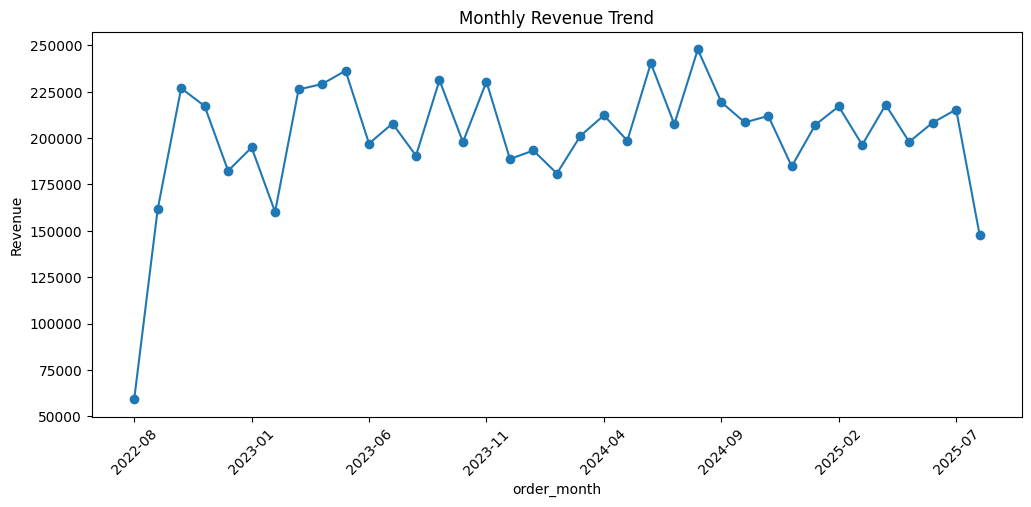

In [38]:
# monthly revenue
monthly_revenue = df.groupby("order_month")["Revenue"].sum()
plt.figure(figsize = (12,5))
monthly_revenue.plot(kind = "line", marker = "o")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.show()

In [39]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age_group',
       'signup_date', 'country', 'product_id', 'product_name', 'category',
       'quantity', 'unit_price', 'order_id', 'order_date', 'order_status',
       'payment_method', 'rating', 'review_text', 'review_date', 'Revenue',
       'customer_tenure_days', 'order_month'],
      dtype='object')

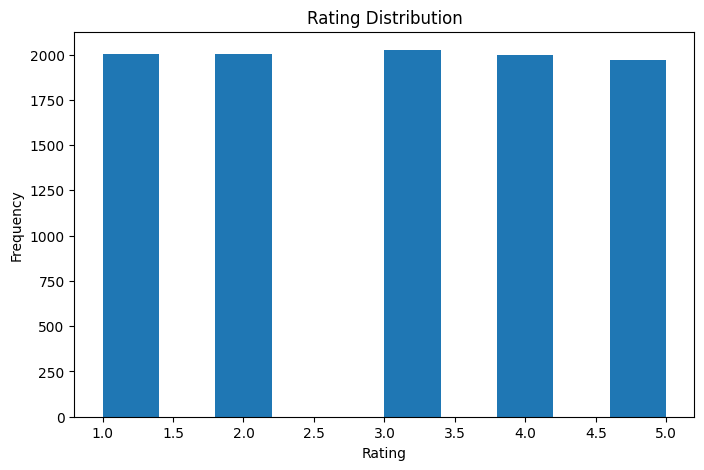

In [40]:
# rating distribution

plt.figure(figsize = (8,5))

df["rating"].plot(kind = "hist", bins = 10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

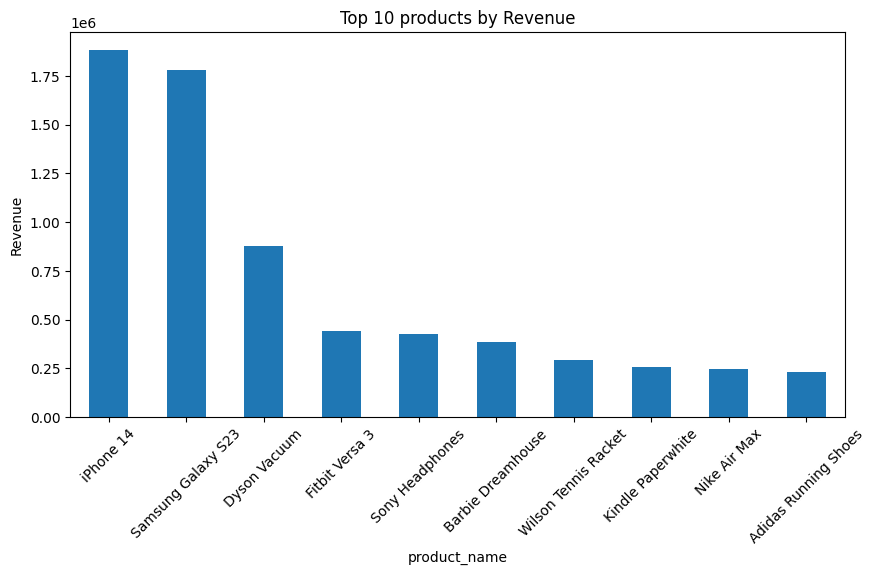

In [41]:
# Top 10 Products by revenue

top_products = df.groupby("product_name")["Revenue"].sum().nlargest(10)

plt.figure(figsize = (10,5))
top_products.plot(kind = "bar")
plt.title("Top 10 products by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)

plt.show()

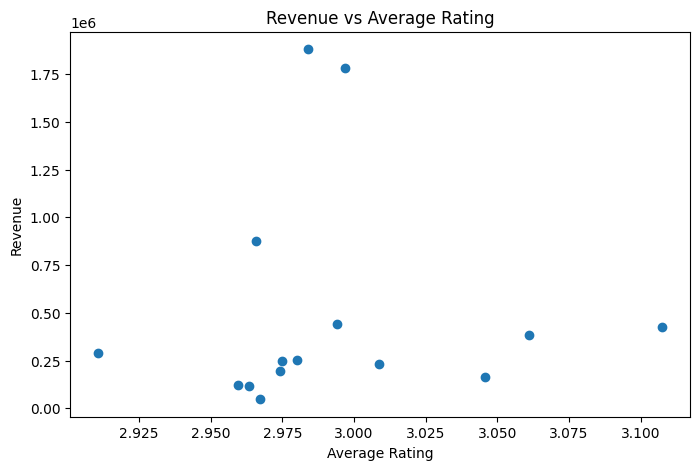

In [42]:
# Revenue vs Rating

product_stats = df.groupby("product_name").agg({"Revenue":"sum","rating":"mean"})

plt.figure(figsize = (8,5))
plt.scatter(product_stats["rating"], product_stats["Revenue"])
plt.title("Revenue vs Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Revenue")
plt.show()

In [43]:
product_stats = df.groupby("product_name").agg({"Revenue":"sum","rating":"mean"})
product_stats

,Revenue,rating
product_name,,
Adidas Running Shoes,230230,3.008824
Barbie Dreamhouse,384667,3.060976
Dyson Vacuum,876204,2.965753
Fitbit Versa 3,442886,2.993930
Harry Potter Box Set,161280,3.045858
Instant Pot,193446,2.974281
Kindle Paperwhite,254517,2.980243
Lego Star Wars Set,115227,2.963526
Levi's Jeans,122366,2.959596
